<a href="https://colab.research.google.com/github/transerena01/serenaTweetsSentimentAnalysis/blob/main/SentimentAnalysiswithNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Serena Tran - Sentiment Analysis with LSTM Neural Network

in lieu of practice for the TweetsSentimentPredictions.ipynb tutorial


Purpose: build a sentiment analysis model
that can classify text comments into sentiment categories using Natural Language Processing (NLP) and Deep Learning.



The project follows these main steps:

1. Import libraries
2. explore the dataset
3. Clean text data, encode sentiment labels
5. Tokenize and sequence text
6. Split training and testing data
7. Build and train the LSTM model
8. Evaluate model performance
9. Visualize results
10. Test the model on new comments



In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.4 MB/s eta 0:00:00


# Imports

In [ ]:
import re
import matplotlib.pyplot as plt
import string
from nltk.corpus import stopwords
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize.treebank import TreebankWordDetokenizer
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import gensim
from sklearn.model_selection import train_test_split
import spacy
import pickle
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
print('Done')

Done


# Data importing

In [ ]:
import os
os.listdir()

train = pd.read_csv("archive (1).zip")

# Data exploration

In [ ]:
#explores the dataset structure and checks the available columns and sentiment categories

train = train.rename(columns={
    "text": "selected_text"
})

In [ ]:

#The dataset columns are renamed to simpler names that are easier to work with throughout the project.


train = train.rename(columns={
    "Comment": "selected_text",
    "Sentiment": "sentiment"
})

In [ ]:
train.columns

Index(['Unnamed: 0', 'selected_text', 'sentiment'], dtype='object')

In [ ]:
train["sentiment"].unique()

array([1, 0, 2])

# Data cleaning



### The next steps about data cleaning will be:

- removing URLs
- removing emails
- removing extra spaces
- converting emojis into words
- removing stopwords
- tokenizing text

In [ ]:
#Let's keep only the columns that we're going to use
train = train[['selected_text','sentiment']]
train.head()

,selected_text,sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [ ]:
#Is there any null value?
train["selected_text"].isnull().sum()

np.int64(217)

In [ ]:
#Let's fill the only null value.
train["selected_text"].fillna("No content", inplace=True)

In [30]:
!pip install emoji

import re
import gensim
import nltk
import emoji
import numpy as np

from nltk.corpus import stopwords
from nltk.tokenize.treebank import TreebankWordDetokenizer

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

#removes unnecessary text elements that may reduce model performance.

def depure_data(data):
    data = str(data)

    # turn emojis into words
    # 😭 -> :loudly_crying_face:
    data = emoji.demojize(data)

    # keep hashtag words, but remove the # symbol
    # #BTS -> BTS
    data = re.sub(r"#(\w+)", r"\1", data)

    # remove URLs
    data = re.sub(r'https?://\S+|www\.\S+', '', data)

    # remove emails
    data = re.sub(r'\S*@\S*\s?', '', data)

    # remove extra spaces
    data = re.sub(r'\s+', ' ', data)

    # remove quotes
    data = re.sub(r"\'", "", data)

    return data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#applies the cleaning function to every comment#
temp = []
data_to_list = train["selected_text"].values.tolist()
for i in range(len(data_to_list)):
    temp.append(depure_data(data_to_list[i]))
print(temp[:5])

['lets forget apple pay required brand new iphone order use significant portion apples user base wasnt able use even wanted successive iphone incorporated technology older iphones replaced number people could use technology increased', 'nz retailers don’t even contactless credit card machines like paywave support apple pay don’t like high fees come', 'forever acknowledge channel help lessons ideas explanations quite helpful youll sit comfort monitor account growth', 'whenever go place doesn’t take apple pay doesn’t happen often it’s drag ‘contactless covid’ habits getting apple card i’ve gotten used apple pay get seriously annoyed store doesn’t take feels like shock it’s crazy quickly took shopping routine i’ve officially brainwashed apple feels inconvenient even carry physical card pocket', 'apple pay convenient secure easy use used korean japanese airports need physical credit cards']


## Tokenization

Converts sentences into lists of individual words.

Stopwords such as: the, is, and

are removed because they do not contribute  meaning.


In [ ]:
def sent_to_words(sentences):
    for sentence in sentences:
        words = gensim.utils.simple_preprocess(str(sentence), deacc=True)
        words = [
            word for word in words
            if word not in stop_words
        ]
        yield words
data_words = list(sent_to_words(temp))
print(data_words[:10])

[['lets', 'forget', 'apple', 'pay', 'required', 'brand', 'new', 'iphone', 'order', 'use', 'significant', 'portion', 'apples', 'user', 'base', 'wasnt', 'able', 'use', 'even', 'wanted', 'successive', 'iphone', 'incorporated', 'technology', 'older', 'iphones', 'replaced', 'number', 'people', 'could', 'use', 'technology', 'increased'], ['nz', 'retailers', 'even', 'contactless', 'credit', 'card', 'machines', 'like', 'paywave', 'support', 'apple', 'pay', 'like', 'high', 'fees', 'come'], ['forever', 'acknowledge', 'channel', 'help', 'lessons', 'ideas', 'explanations', 'quite', 'helpful', 'youll', 'sit', 'comfort', 'monitor', 'account', 'growth'], ['whenever', 'go', 'place', 'take', 'apple', 'pay', 'happen', 'often', 'drag', 'contactless', 'covid', 'habits', 'getting', 'apple', 'card', 'gotten', 'used', 'apple', 'pay', 'get', 'seriously', 'annoyed', 'store', 'take', 'feels', 'like', 'shock', 'crazy', 'quickly', 'took', 'shopping', 'routine', 'officially', 'brainwashed', 'apple', 'feels', 'inco

In [ ]:
# After cleaning and tokenization, the words are combined back into cleaned sentences

def detokenize(text):
    return TreebankWordDetokenizer().detokenize(text)
data = []

for i in range(len(data_words)):
    data.append(detokenize(data_words[i]))
data = np.array(data)
print(data[:5])

['lets forget apple pay required brand new iphone order use significant portion apples user base wasnt able use even wanted successive iphone incorporated technology older iphones replaced number people could use technology increased'
 'nz retailers even contactless credit card machines like paywave support apple pay like high fees come'
 'forever acknowledge channel help lessons ideas explanations quite helpful youll sit comfort monitor account growth'
 'whenever go place take apple pay happen often drag contactless covid habits getting apple card gotten used apple pay get seriously annoyed store take feels like shock crazy quickly took shopping routine officially brainwashed apple feels inconvenient even carry physical card pocket'
 'apple pay convenient secure easy use used korean japanese airports need physical credit cards']


# Label encoding

Neural networks cannot understand text labels directly.
This section converts sentiment categories into numerical format

In [ ]:
labels = tf.keras.utils.to_categorical(
    train["sentiment"], 3
)
print(labels[:5])
print(len(labels))

[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]
241145


# Data sequencing and splitting

The tokenizer converts words --> integer values.
Padding ensures every sentence has the same length so the neural network can process the data correctly.

In [13]:
import re
import gensim
import numpy as np
import nltk

from nltk.corpus import stopwords
from nltk.tokenize.treebank import TreebankWordDetokenizer
import pandas as pd

train = pd.read_csv("archive (1).zip")

train = train.rename(columns={
    "Comment": "selected_text",
    "Sentiment": "sentiment"
})

train.head()

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def depure_data(data):
    data = str(data)
    data = re.sub(r'https?://\S+|www\.\S+', '', data)
    data = re.sub(r'\S*@\S*\s?', '', data)
    data = re.sub(r'\s+', ' ', data)
    data = re.sub(r"\'", "", data)
    return data

def sent_to_words(sentences):
    for sentence in sentences:
        words = gensim.utils.simple_preprocess(str(sentence), deacc=True)
        words = [word for word in words if word not in stop_words]
        yield words

def detokenize(text):
    return TreebankWordDetokenizer().detokenize(text)

temp = []

data_to_list = train["selected_text"].values.tolist()

for i in range(len(data_to_list)):
    temp.append(depure_data(data_to_list[i]))

data_words = list(sent_to_words(temp))

data = np.array([
    detokenize(words)
    for words in data_words
])

print(data[:5])
print(len(data))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['lets forget apple pay required brand new iphone order use significant portion apples user base wasnt able use even wanted successive iphone incorporated technology older iphones replaced number people could use technology increased'
 'nz retailers even contactless credit card machines like paywave support apple pay like high fees come'
 'forever acknowledge channel help lessons ideas explanations quite helpful youll sit comfort monitor account growth'
 'whenever go place take apple pay happen often drag contactless covid habits getting apple card gotten used apple pay get seriously annoyed store take feels like shock crazy quickly took shopping routine officially brainwashed apple feels inconvenient even carry physical card pocket'
 'apple pay convenient secure easy use used korean japanese airports need physical credit cards']
241145


In [19]:
from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop, Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

from keras import regularizers
from keras import backend as K
from keras.callbacks import ModelCheckpoint

from sklearn.model_selection import train_test_split

max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data)
labels = tf.keras.utils.to_categorical(
    train["sentiment"],
    3
)

print(labels[:5])
print(len(labels))
sequences = tokenizer.texts_to_sequences(data)
tweets = pad_sequences(sequences, maxlen=max_len)

print(tweets)

X_train, X_test, y_train, y_test = train_test_split(
    tweets,
    labels,
    random_state=0
)

print(len(X_train), len(X_test), len(y_train), len(y_test))

print(len(X_train), len(X_test), len(y_train), len(y_test))

[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]
241145
[[   0    0    0 ...  105  790 1187]
 [   0    0    0 ...    3  258   65]
 [   0    0    0 ... 1501  333  548]
 ...
 [   0    0    0 ... 1544 3036  251]
 [   0    0    0 ...  495  317  613]
 [   0    0    0 ...   57  459  146]]
180858 60287 180858 60287
180858 60287 180858 60287


In [ ]:
print(labels)

In [ ]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(tweets,labels, random_state=0)
print (len(X_train),len(X_test),len(y_train),len(y_test))

# Model building

builds the LSTM neural network.

Model layers:
1. Embedding layer
   - converts words into vectors

2. LSTM layer
   - learns patterns and word relationships

3. Dense output layer
   - predicts sentiment probabilities

## SimpleRNN model (Bonus)

In [ ]:
#model0 = Sequential()
#model0.add(layers.Embedding(max_words, 15))
#model0.add(layers.SimpleRNN(15))
#model0.add(layers.Dense(3,activation='softmax'))


#model0.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])
#Implementing model checkpoins to save the best metric and do not lose it on training.
#checkpoint0 = ModelCheckpoint("best_model0.hdf5", monitor='val_accuracy', verbose=1,save_best_only=True, mode='auto', period=1,save_weights_only=False)
#history = model0.fit(X_train, y_train, epochs=5,validation_data=(X_test, y_test),callbacks=[checkpoint0])

## Single LSTM layer model

What :  a type of  neural network designed to process sequential data such as text.


Why: This model depends heavily on word order and context. It can remember previous words in a sentence and use that information to better understand meaning.

* simpler to train,
* easier to explain,
* strong performance for text classification.

How

The text data was first tokenized and converted into padded numerical sequences so the neural network could process it.


In [ ]:
model1 = Sequential()
model1.add(layers.Embedding(max_words, 20))
model1.add(layers.LSTM(15, dropout=0.5))
model1.add(layers.Dense(3, activation="softmax"))

model1.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint1 = ModelCheckpoint(
    "best_model1.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

history = model1.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint1]
)

Epoch 1/5
5652/5652 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6221 - loss: 0.8482
Epoch 1: val_accuracy improved from None to 0.78526, saving model to best_model1.keras

Epoch 1: finished saving model to best_model1.keras
5652/5652 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - accuracy: 0.6996 - loss: 0.7361 - val_accuracy: 0.7853 - val_loss: 0.5902
Epoch 2/5
5652/5652 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7806 - loss: 0.5992
Epoch 2: val_accuracy improved from 0.78526 to 0.79949, saving model to best_model1.keras

Epoch 2: finished saving model to best_model1.keras
5652/5652 ━━━━━━━━━━━━━━━━━━━━ 77s 14ms/step - accuracy: 0.7854 - loss: 0.5862 - val_accuracy: 0.7995 - val_loss: 0.5406
Epoch 3/5
5651/5652 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7976 - loss: 0.5486
Epoch 3: val_accuracy improved from 0.79949 to 0.80777, saving model to best_model1.keras

Epoch 3: finished saving model to best_model1.keras
5652/5652 ━━━━━━━━━━━━━━━━━━━━ 109s 19ms/step - accuracy: 0.7981 - l

In [27]:
test_loss, test_acc = model1.evaluate(X_test, y_test, verbose=2)

print("Model accuracy:", test_acc)
predictions = model1.predict(X_test)

1884/1884 - 15s - 8ms/step - accuracy: 0.8117 - loss: 0.5094
Model accuracy: 0.8116841316223145
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step


## CONFUSION MATRIX

The confusion matrix compares:
- actual sentiment
- predicted sentiment

Class 0 = negative
Class 1 = neutral
Class 2 = positive

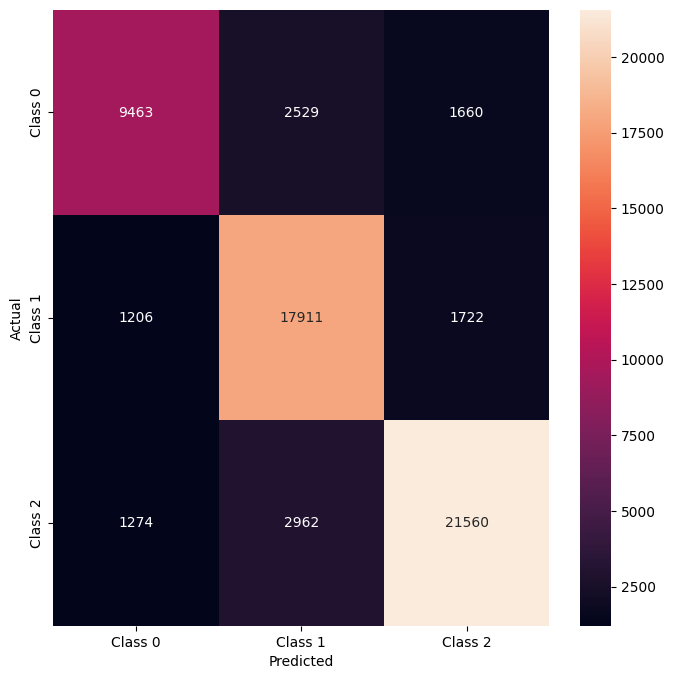

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matrix = confusion_matrix(true_classes, predicted_classes)

conf_matrix = pd.DataFrame(
    matrix,
    index=["Class 0", "Class 1", "Class 2"],
    columns=["Class 0", "Class 1", "Class 2"]
)

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

bar chart shows how many comments were predicted
for each sentiment class.

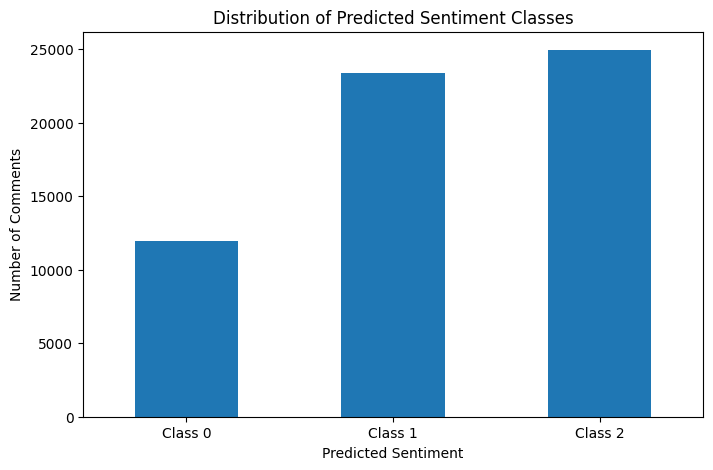

In [31]:


prediction_counts = pd.Series(
    predicted_classes
).value_counts().sort_index()

prediction_counts.index = [
    "Class 0",
    "Class 1",
    "Class 2"
]

plt.figure(figsize=(8, 5))

prediction_counts.plot(kind="bar")

plt.xlabel("Predicted Sentiment")
plt.ylabel("Number of Comments")
plt.title("Distribution of Predicted Sentiment Classes")

plt.xticks(rotation=0)

plt.show()

## Testing
tests the model on new comments that were
not included in the original dataset.

In [29]:
sentiment = ["Class 0", "Class 1", "Class 2"]

my_comments = [
    "this comeback is amazing",
    "this song is boring",
    "the music video was released today",
    "i love their vocals",
    "this fandom is so toxic"
]

for comment in my_comments:
    sequence = tokenizer.texts_to_sequences([comment])
    test = pad_sequences(sequence, maxlen=max_len)
    pred = model1.predict(test)
    print(comment, "->", sentiment[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
this comeback is amazing -> Class 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
this song is boring -> Class 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
the music video was released today -> Class 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
i love their vocals -> Class 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
this fandom is so toxic -> Class 1
